In [ ]:
pip install ipywidgets
jupyter nbextension enable --py widgetsnbextension

In [ ]:
import shutil, os
pycache_path = "__pycache__"  # adjust path if functions_v2.py isn't in the notebook's directory
if os.path.exists(pycache_path):
    shutil.rmtree(pycache_path)
    print("Deleted __pycache__")
else:
    print("No __pycache__ found here — check the correct project directory")

In [2]:
import numpy as np
import functions_v2
from functions_v2 import *

In [8]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import random
from tqdm import tqdm

In [12]:
edges, n_vertices, edge_weights = load_graph("../summer-project/bio-CE-GN.edges")

✓ Loaded: ../summer-project/bio-CE-GN.edges
  Vertices : 2220
  Edges    : 53683
  Weighted : yes



In [14]:
# discard the edge weights
edge_weights = None

In [16]:
# check for isolated nodes (nodes with no edges)
referenced_nodes = set(v for e in edges for v in e)
print(f"Referenced nodes: {len(referenced_nodes)}, n_vertices: {n_vertices}")
print(f"Missing/isolated node IDs: {n_vertices - len(referenced_nodes)}")

Referenced nodes: 2220, n_vertices: 2220
Missing/isolated node IDs: 0


In [18]:
all_nodes = set(v for e in edges for v in e)
print(min(all_nodes), max(all_nodes), len(all_nodes))

0 2219 2220


# Community Detection

In [20]:
random.seed(42)  # reproducibility

G_nx = nx.Graph()
G_nx.add_edges_from(edges)

# 1. Detect communities
communities = list(greedy_modularity_communities(G_nx))
print(f"Found {len(communities)} communities")
for i, c in enumerate(communities):
    print(f"  Community {i}: {len(c)} nodes")

Found 18 communities
  Community 0: 816 nodes
  Community 1: 726 nodes
  Community 2: 474 nodes
  Community 3: 56 nodes
  Community 4: 35 nodes
  Community 5: 29 nodes
  Community 6: 20 nodes
  Community 7: 18 nodes
  Community 8: 15 nodes
  Community 9: 7 nodes
  Community 10: 5 nodes
  Community 11: 4 nodes
  Community 12: 3 nodes
  Community 13: 3 nodes
  Community 14: 3 nodes
  Community 15: 2 nodes
  Community 16: 2 nodes
  Community 17: 2 nodes


In [22]:
# 2. Filter out tiny/noise communities
min_size = 10  # adjust based on what you see in the output above
significant_communities = [c for c in communities if len(c) >= min_size]
print(f"{len(significant_communities)} communities with >= {min_size} nodes")

9 communities with >= 10 nodes


In [24]:
# 3. Find the two communities with the LARGEST average shortest-path distance
#    (most geometrically separated — best fit for a flow/travel-distance story)
def avg_intercommunity_distance(G, comm_a, comm_b, sample_size=30):
    """Samples nodes from each community to keep this fast on large communities."""
    a_nodes = list(comm_a)
    b_nodes = list(comm_b)
    if len(a_nodes) > sample_size:
        a_nodes = random.sample(a_nodes, sample_size)
    if len(b_nodes) > sample_size:
        b_nodes = random.sample(b_nodes, sample_size)

    dists = []
    for u in a_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        for v in b_nodes:
            if v in lengths:
                dists.append(lengths[v])
    return sum(dists) / len(dists) if dists else float('inf')

In [26]:
best_pair = None
max_dist = -1
for i in range(len(significant_communities)):
    for j in range(i + 1, len(significant_communities)):
        d = avg_intercommunity_distance(G_nx, significant_communities[i], significant_communities[j])
        print(f"  pair ({i},{j}): sizes {len(significant_communities[i])}/{len(significant_communities[j])}, avg dist = {d:.2f}")
        if d > max_dist:
            max_dist = d
            best_pair = (i, j)

comm_a = significant_communities[best_pair[0]]
comm_b = significant_communities[best_pair[1]]
print(f"\nSelected communities {best_pair}: sizes {len(comm_a)}, {len(comm_b)}, avg distance: {max_dist:.2f}")

  pair (0,1): sizes 816/726, avg dist = 2.64
  pair (0,2): sizes 816/474, avg dist = 2.70
  pair (0,3): sizes 816/56, avg dist = 2.98
  pair (0,4): sizes 816/35, avg dist = 2.80
  pair (0,5): sizes 816/29, avg dist = 3.23
  pair (0,6): sizes 816/20, avg dist = 2.91
  pair (0,7): sizes 816/18, avg dist = 3.08
  pair (0,8): sizes 816/15, avg dist = 3.14
  pair (1,2): sizes 726/474, avg dist = 2.56
  pair (1,3): sizes 726/56, avg dist = 3.30
  pair (1,4): sizes 726/35, avg dist = 3.00
  pair (1,5): sizes 726/29, avg dist = 3.40
  pair (1,6): sizes 726/20, avg dist = 2.83
  pair (1,7): sizes 726/18, avg dist = 3.32
  pair (1,8): sizes 726/15, avg dist = 3.32
  pair (2,3): sizes 474/56, avg dist = 3.22
  pair (2,4): sizes 474/35, avg dist = 2.87
  pair (2,5): sizes 474/29, avg dist = 3.24
  pair (2,6): sizes 474/20, avg dist = 3.01
  pair (2,7): sizes 474/18, avg dist = 3.29
  pair (2,8): sizes 474/15, avg dist = 3.40
  pair (3,4): sizes 56/35, avg dist = 3.20
  pair (3,5): sizes 56/29, avg

In [28]:
gamma_in = list(comm_a)
gamma_out = list(comm_b)
print(f"gamma_in: {len(gamma_in)} nodes, gamma_out: {len(gamma_out)} nodes")

gamma_in: 18 nodes, gamma_out: 15 nodes


In [30]:
comm_a = communities[0]  # 816 nodes
comm_b = communities[1]  # 726 nodes

# edges within community A
edges_in_a = sum(1 for u, v in G_nx.edges() if u in comm_a and v in comm_a)

# edges within community B
edges_in_b = sum(1 for u, v in G_nx.edges() if u in comm_b and v in comm_b)

# edges between A and B (the "inter-community" edges — these matter for how connected your source/sink regions are to each other)
edges_between = sum(1 for u, v in G_nx.edges() 
                     if (u in comm_a and v in comm_b) or (u in comm_b and v in comm_a))

print(f"Edges within community A (816 nodes): {edges_in_a}")
print(f"Edges within community B (726 nodes): {edges_in_b}")
print(f"Edges between A and B: {edges_between}")
print(f"Total edges involving A or B: {edges_in_a + edges_in_b + edges_between}")

Edges within community A (816 nodes): 15814
Edges within community B (726 nodes): 11993
Edges between A and B: 9405
Total edges involving A or B: 37212


In [32]:
print(f"Within A: {edges_in_a}")
print(f"Within B: {edges_in_b}")
print(f"Between A and B: {edges_between}")

Within A: 15814
Within B: 11993
Between A and B: 9405


In [ ]:
gamma_in = list(comm_a)   # 816 nodes, community A
gamma_out = list(comm_b)  # 726 nodes, community B

In [ ]:
import networkx as nx
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

num_components = nx.number_connected_components(G_nx)
print(f"Connected components: {num_components}")

component_sizes = sorted([len(c) for c in nx.connected_components(G_nx)], reverse=True)
print(f"Component sizes: {component_sizes}")

# bio-CE-GN — Connectivity Issue & Design Choices

## Issue Found
- `compute_lambda_min` raised `AssertionError: No positive eigenvalues found`
- Root cause: graph is **not fully connected**
  - 3 connected components: sizes **2215**, **3**, **2**
  - The two smallest eigenvalues `eigsh` returned were both ≈0 (one per disconnected component), so no positive eigenvalue was found among them

## Fix Applied
- Kept only the **largest connected component** (2215 of 2220 nodes)
- Dropped the two tiny fragments (3 nodes, 2 nodes — isolated, disconnected from the rest of the network)
- Remapped node IDs to be contiguous (0 to 2214) after filtering
- Re-ran community detection on the cleaned, connected graph before reselecting `gamma_in` / `gamma_out`

## Why This Is a Reasonable Fix
- Standard practice in network science: spectral graph methods (including this Laplacian shift/eigenvalue approach) require a connected graph — a disconnected graph has one zero eigenvalue per component, which breaks the shift formulation
- Excluded nodes are a negligible fraction of the graph (5 of 2220 — 0.2%)
- No meaningful structure lost: fragments were isolated node pairs/triples with no bearing on the graph's dominant modular structure

## Gamma_in / Gamma_out Selection — Rationale Across Datasets
- **Rhesus Brain:** degree-based (hub vs. periphery) — fit because the graph has clear hub-and-spoke structure
- **Power Grid / Oregon:** diameter endpoints (max shortest-path distance) — fit because there's no dominant hub structure, but meaningful geometric extremes exist
- **bio-CE-GN:** community detection (greedy modularity) — fit because the graph shows strong modular structure (2 large dominant communities + long tail of small ones), not a hub-spoke or clean diameter pattern

**General principle:** gamma_in/gamma_out selection is structure-informed per dataset, not a fixed universal method — each choice matches the graph's actual topology rather than applying one recipe uniformly.

## bio-CE-GN Community Structure (pre-connectivity-fix numbers, to be re-verified post-fix)
- 18 communities detected via greedy modularity
- Highly skewed: 2 dominant communities (816, 726 nodes) + long tail down to single-digit sizes
- Selected communities A (816) and B (726) as gamma_in / gamma_out — largest, most structurally substantial modules
- Edge breakdown:
  - Within A: 15,814
  - Within B: 11,993
  - Between A and B: 9,405
  - Remaining (elsewhere in graph): ~16,471

## Open Question for Prof
- Comfortable with per-dataset, structure-informed gamma selection (vs. one fixed method across all datasets)?
- Confirm exclusion of the 5-node disconnected fragments is acceptable for the paper's methodology section

In [ ]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

largest_cc = max(nx.connected_components(G_nx), key=len)
G_sub = G_nx.subgraph(largest_cc).copy()

# remap node IDs to be contiguous 0...n-1
all_nodes = sorted(largest_cc)
node_map = {old: new for new, old in enumerate(all_nodes)}
edges = [(node_map[i], node_map[j]) for i, j in G_sub.edges()]
n_vertices = len(all_nodes)

print(f"New n_vertices: {n_vertices}")
print(f"New edge count: {len(edges)}")

In [38]:
# running community detection again after disconnecting the components
random.seed(42)  # reproducibility

G_nx = nx.Graph()
G_nx.add_edges_from(edges)

# 1. Detect communities
communities = list(greedy_modularity_communities(G_nx))
print(f"Found {len(communities)} communities")
for i, c in enumerate(communities):
    print(f"  Community {i}: {len(c)} nodes")

# 2. Filter out tiny/noise communities
min_size = 10  # adjust based on what you see in the output above
significant_communities = [c for c in communities if len(c) >= min_size]
print(f"{len(significant_communities)} communities with >= {min_size} nodes")

# 3. Find the two communities with the LARGEST average shortest-path distance
#    (most geometrically separated — best fit for a flow/travel-distance story)
def avg_intercommunity_distance(G, comm_a, comm_b, sample_size=30):
    """Samples nodes from each community to keep this fast on large communities."""
    a_nodes = list(comm_a)
    b_nodes = list(comm_b)
    if len(a_nodes) > sample_size:
        a_nodes = random.sample(a_nodes, sample_size)
    if len(b_nodes) > sample_size:
        b_nodes = random.sample(b_nodes, sample_size)

    dists = []
    for u in a_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        for v in b_nodes:
            if v in lengths:
                dists.append(lengths[v])
    return sum(dists) / len(dists) if dists else float('inf')

best_pair = None
max_dist = -1
for i in range(len(significant_communities)):
    for j in range(i + 1, len(significant_communities)):
        d = avg_intercommunity_distance(G_nx, significant_communities[i], significant_communities[j])
        print(f"  pair ({i},{j}): sizes {len(significant_communities[i])}/{len(significant_communities[j])}, avg dist = {d:.2f}")
        if d > max_dist:
            max_dist = d
            best_pair = (i, j)

comm_a = significant_communities[best_pair[0]]
comm_b = significant_communities[best_pair[1]]
print(f"\nSelected communities {best_pair}: sizes {len(comm_a)}, {len(comm_b)}, avg distance: {max_dist:.2f}")

gamma_in = list(comm_a)
gamma_out = list(comm_b)
print(f"gamma_in: {len(gamma_in)} nodes, gamma_out: {len(gamma_out)} nodes")

Found 18 communities
  Community 0: 816 nodes
  Community 1: 726 nodes
  Community 2: 474 nodes
  Community 3: 56 nodes
  Community 4: 35 nodes
  Community 5: 29 nodes
  Community 6: 20 nodes
  Community 7: 18 nodes
  Community 8: 15 nodes
  Community 9: 7 nodes
  Community 10: 5 nodes
  Community 11: 4 nodes
  Community 12: 3 nodes
  Community 13: 3 nodes
  Community 14: 3 nodes
  Community 15: 2 nodes
  Community 16: 2 nodes
  Community 17: 2 nodes
9 communities with >= 10 nodes
  pair (0,1): sizes 816/726, avg dist = 2.64
  pair (0,2): sizes 816/474, avg dist = 2.70
  pair (0,3): sizes 816/56, avg dist = 2.98
  pair (0,4): sizes 816/35, avg dist = 2.80
  pair (0,5): sizes 816/29, avg dist = 3.23
  pair (0,6): sizes 816/20, avg dist = 2.91
  pair (0,7): sizes 816/18, avg dist = 3.08
  pair (0,8): sizes 816/15, avg dist = 3.14
  pair (1,2): sizes 726/474, avg dist = 2.56
  pair (1,3): sizes 726/56, avg dist = 3.30
  pair (1,4): sizes 726/35, avg dist = 3.00
  pair (1,5): sizes 726/29,

In [40]:
communities_sorted = sorted(communities, key=len, reverse=True)

comm_a = communities_sorted[0]  # 816 nodes
comm_b = communities_sorted[1]  # 736 nodes

gamma_in = list(comm_a)
gamma_out = list(comm_b)

print(f"gamma_in size: {len(gamma_in)}, max node id: {max(gamma_in)}")
print(f"gamma_out size: {len(gamma_out)}, max node id: {max(gamma_out)}")
print(f"n_vertices: {n_vertices}")

gamma_in size: 816, max node id: 2218
gamma_out size: 726, max node id: 2219
n_vertices: 2220


In [42]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 2220 x 2220
  Degree range: [1, 242]
  Non-zeros in L: 109586



In [44]:
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)

AssertionError: No positive eigenvalues found — is the graph connected?

In [ ]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

In [ ]:
comm_a = communities[0]  # 816 nodes
comm_b = communities[1]  # 726 nodes

In [ ]:
gamma_in = list(comm_a)   # 816 nodes, community A
gamma_out = list(comm_b)  # 726 nodes, community B

In [ ]:
k = compute_permeability(u, edges, edge_weights)

In [ ]:
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [ ]:
p = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

In [ ]:
Q = extract_qoi(p, k, edges, gamma_out)
print(f"Single-sample Q: {Q}")

In [ ]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1500, use_amg=False)

In [ ]:
analyze_qoi(Q_samples)

In [ ]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1500, use_amg=False)

In [ ]:
print(f"gamma_in size: {len(gamma_in)}")
print(f"gamma_out size: {len(gamma_out)}")

# how many edges actually touch a gamma_out node? (this is what extract_qoi sums over)
outlet_edges = [(i,j) for i,j in edges if i in set(gamma_out) or j in set(gamma_out)]
print(f"Edges touching gamma_out: {len(outlet_edges)}")

In [ ]:
outlet_edges = [(i,j) for i,j in edges if i in set(gamma_out) or j in set(gamma_out)]
print(f"Edges touching gamma_out: {len(outlet_edges)}")
print(f"Mean Q per outlet edge: {11981.186196 / len(outlet_edges):.4f}")

## Q-value scale mismatch — bio-CE-GN vs. other datasets

**Issue found:** Raw Monte Carlo results for bio-CE-GN converged cleanly (1500 samples, ~2 min runtime), but the mean Q value was ~1000x larger than the other three datasets:## Q-value comparison across datasets — raw vs. normalized

| Dataset | Raw Mean Q | Gamma_in size | Inlet edges | Gamma_out size | Outlet edges | Normalized Q |
|---|---|---|---|---|---|---|
| Rhesus Brain | 9.20 | 5 | 345 | 5 | 9 | 1.0222 |
| US Power Grid | 3.62 | 23 | 81 | 14 | 23 | 0.1574 |
| bio-CE-GN | 11,981.19 | 816 | — | 736 | 25,866 | 0.4632 |
| Oregon Router | *pending full MC run* | 11 | — | 92 | 5,154 | *pending* |

**Normalization:** Normalized Q = Raw Mean Q / (edges touching gamma_out). Corrects for the large variation in outlet set size across gamma-selection methods (degree-based for Rhesus, diameter-endpoint for Power Grid/Oregon, community-based for bio-CE-GN) — raw Q scales with the number of terms summed in `extract_qoi`, not just the underlying flow physics, so it isn't directly comparable across datasets without this correction.

**Note:** normalized values still differ across datasets by ~6x (0.16 to 1.02) even after correcting for outlet-edge-count — this is expected, since normalization only removes the summation-size artifact, not genuine differences in graph structure, permeability distribution, or gamma placement.

**Also note:** Rhesus Brain's gamma_in (5 nodes) touches 345 edges — notably more than its gamma_out (5 nodes, 9 edges) despite equal set size, reflecting the hub-vs-periphery asymmetry inherent to the degree-based selection method (low-degree inlet nodes are individually sparse, but as a group sit in a differently-connected region than the high-degree hub outlet).

**To fill in:** bio-CE-GN and Oregon inlet edge counts, Oregon's converged mean Q once the full Monte Carlo run completes.1,981 |

**Root cause:** `extract_qoi` sums flux (`Q = Σ k_e \|p_i - p_j\|`) over every edge touching `gamma_out`. Because bio-CE-GN's gamma_in/gamma_out were selected via community detection (entire communities used as source/sink), the sink set (`gamma_out`) contains **736 nodes** — versus a small handful of nodes (degree- or diameter-based) in the other datasets. This means the QoI sum for bio-CE-GN is taken over **25,866 outlet edges**, nearly half the graph's total 53,680 edges, while the other datasets summed over far fewer.

**Confirmation:** normalizing by outlet edge count brings the value back in line with the other datasets:
- Mean Q per outlet edge = 11,981.19 / 25,866 = **0.4632**
- This is now in the same order of magnitude as Power Grid (3.62), consistent with the difference being a counting artifact rather than a real physical signal about the graph.

**Conclusion:** the bio-CE-GN Monte Carlo run itself (white noise sampling, permeability generation, Darcy solve) is valid — the issue is specifically that **raw Q is not directly comparable across datasets when gamma_out cardinality varies by orders of magnitude.**

**Proposed fix — two options:**
1. **Report both raw Q and normalized Q (per outlet edge)** for all four datasets going forward, using normalized Q as the primary cross-dataset comparison metric. Keeps the current 1500-sample run; no rerun needed.
2. **Rerun with a smaller, representative gamma_in/out** (e.g. top-k most central nodes per community by degree) to bring gamma set sizes closer to the other datasets' scale. Preserves the community-informed selection principle, but requires a fresh Monte Carlo run.

**Recommendation:** Option 1 — keep existing results, add normalized Q per outlet edge as the standard comparison metric across all datasets.

**Question for prof:** should normalized Q (per outlet edge) be the standard reported metric across all four datasets, or should gamma_in/out sizes be brought closer in line across datasets instead?

## AMG question — is L_k rebuilt every sample?

- **Yes, `L_k` is rebuilt every Monte Carlo sample** — this is correct/necessary, not a bug:
  - Each sample draws a new white noise field `u`
  - New `u` → new permeability `k` (since `k_e = exp((u_i + u_j)/2)`)
  - New `k` → new weighted Laplacian `L_k`
  - Each sample is a physically different random realization, so `L_k` can't be reused across samples

- **Consequence for AMG:** since `L_k` changes every sample, `solve_darcy_amg` also rebuilds the entire AMG multigrid hierarchy from scratch every call (`pyamg.ruge_stuben_solver(L_interior)`) — no reuse across samples

- **Why this matters:** AMG's advantage comes from *amortizing* an expensive one-time setup cost across many fast repeated solves against the *same* matrix. That doesn't apply here — every sample has a genuinely different matrix, so AMG setup cost is paid N times with zero reuse.

- **Practical result:** this is likely why direct `spsolve` outperforms AMG at bio-CE-GN's scale (2,215 nodes) — consistent with the original guidance that AMG is only worth it above ~50k nodes, where per-solve savings can outweigh setup cost even without reuse

- **Confirmed empirically:** bio-CE-GN converged in ~2 min for 1500 samples using `use_amg=False` (direct `spsolve`) — no indication AMG is needed at this graph size

- **Possible future optimization (if relevant):** `L_interior`'s sparsity pattern stays identical across samples (only edge *weights* change, not graph topology) — could explore reusing symbolic factorization (e.g. `splu` with fixed permutation) across samples, though current runtime may not justify the added complexity

# Selecting gamma_in and gamma_out 

## Approach 1: Degree-based gamma_in/gamma_out (e.g. Rhesus Brain)

**When to use:** graph has clear hub-and-spoke structure — a small cluster of very high-degree nodes, clearly separated from many low-degree nodes.

**Logic:**
- `gamma_in` (source) = low-degree, peripheral nodes
- `gamma_out` (sink) = high-degree, hub nodes
- Direction (periphery → hub) matches the graph's natural connective structure

**Implementation steps:**
1. Compute degree for every node (`G_nx.degree()`)
2. Plot a degree histogram — confirm hub-and-spoke shape before proceeding (look for a small cluster of high-degree outliers vs. a big mass of low-degree nodes)
3. Pick a cutoff:
   - Simple: top/bottom `k` nodes by degree (arbitrary, less defensible)
   - Better: percentile-based (e.g. bottom 10% = gamma_in, top 10% = gamma_out) — reproducible, easy to justify in the paper
4. Sanity check: assert `gamma_in` and `gamma_out` don't overlap

**Why percentile > arbitrary k:** "top/bottom 10th percentile by degree" is a clear, reproducible rule; "we picked 10 nodes" invites the same justification problem as an arbitrary k in the community-detection approach.

## Approach 2: Community detection (bio-CE-GN)

**When to use:** graph has strong modular structure — clear, distinct communities rather than a hub-spoke pattern or a spread-out geometry. Fails when communities overlap heavily or aren't clearly separable (e.g. US Power Grid).

**Logic:**
- Run community detection (greedy modularity) on the full graph
- Filter out tiny/noise communities (`min_size` threshold)
- Select the two **largest** communities as source/sink — not the "most distant" pair, since maximizing distance tends to select small, unrepresentative fragments rather than real structural modules
- `gamma_in` = entire largest community, `gamma_out` = entire second-largest community

**Implementation steps:**
1. Build graph, confirm it's fully connected first (`nx.number_connected_components` — spectral steps downstream require this)
2. Run `greedy_modularity_communities(G_nx)`
3. Print community sizes — check for a clear "dominant communities vs. long tail" pattern
4. Sort by size, take the top two directly as `gamma_in`/`gamma_out`
5. Check edge breakdown (within A, within B, between A/B) to confirm they're meaningfully distinct, densely-connected modules

**Caveat found in practice:** using whole communities as gamma sets can make them very large (hundreds of nodes) — this inflates raw Q (since `extract_qoi` sums over every outlet edge) and makes it non-comparable to datasets with small gamma sets. Normalize by outlet edge count for cross-dataset comparison.

**Fails when:** communities are heavily overlapping or not clearly separable — no dominant, distinct modules to select from (this is what happened with US Power Grid, motivating Approach 3 instead).


## Approach 3: Diameter endpoints (US Power Grid, Oregon Router)

**When to use:** no clear hub-spoke structure (Approach 1 doesn't fit) and no clean, distinct community structure (Approach 2 doesn't fit) — but the graph still has meaningful geometric extent, so picking the two most topologically distant points is a principled choice.

**Logic:**
- Find the two vertices that are farthest apart (in hop count) — approximates the graph's diameter
- `gamma_in` = k-hop neighborhood around one endpoint
- `gamma_out` = k-hop neighborhood around the other endpoint
- Forces flow to traverse close to the graph's maximum possible distance — a meaningful "worst case" flow path

**Implementation steps (double BFS — approximate diameter, exact is too expensive for large graphs):**
1. Pick a few sample starting nodes (`n_sample`)
2. From each start, BFS to find the farthest vertex `v`
3. From `v`, BFS again to find the farthest vertex `w` — `v` and `w` approximate the diameter endpoints
4. Repeat from multiple starting points, keep the best (longest) pair found
5. Build `gamma_in`/`gamma_out` as k-hop neighborhoods around `v` and `w` (not just the single endpoint — gives a small region rather than one node)
6. Remove any overlap between `gamma_in` and `gamma_out` before finalizing

```python
def find_diameter_endpoints(G_nx, n_sample=5, k_hop=4):
    best_dist = 0
    best_v, best_w = None, None
    start_nodes = list(G_nx.nodes())[:n_sample]

    for start in start_nodes:
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w

    gamma_in  = set(nx.single_source_shortest_path_length(G_nx, best_v, cutoff=k_hop).keys())
    gamma_out = set(nx.single_source_shortest_path_length(G_nx, best_w, cutoff=k_hop).keys())

    gamma_in  = gamma_in - gamma_out
    gamma_out = gamma_out - gamma_in

    return list(map(int, gamma_in)), list(map(int, gamma_out)), best_dist

gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx_power, k_hop=4)
```

**Tunable:** `k_hop` controls gamma set size — larger `k_hop` gives bigger source/sink regions. Adjust based on desired gamma set size relative to graph size.

**Why this fits Power Grid/Oregon:** no dominant hub, no clean separable communities — but real geometric/topological extent (opposite ends of a large infrastructure network), which diameter endpoints captures directly.

# Two-level method

In [ ]:
from scipy.sparse import coo_matrix

In [ ]:
edges_arr = np.array(edges)
i_arr = edges_arr[:, 0]
j_arr = edges_arr[:, 1]

row_idx = np.concatenate([i_arr, j_arr, i_arr, j_arr])
col_idx = np.concatenate([i_arr, j_arr, j_arr, i_arr])

In [ ]:
import time
import numpy as np
from scipy.sparse.linalg import spsolve, cg
import pyamg

# Run this on your REAL L_sigma-derived setup for bio-CE-GN
N_test = 15
spsolve_times = []
twolevel_times = []
p_direct_list = []
p_twolevel_list = []

boundary = list(set(gamma_in) | set(gamma_out))
interior = np.array([v for v in range(n_vertices) if v not in set(boundary)])
p_boundary_template = np.zeros(n_vertices)
for v in gamma_in:
    p_boundary_template[v] = 1.0

for trial in range(N_test):
    w = np.random.randn(len(edges))
    f = B @ w
    u = cho_solve(cho_cache, np.sqrt(lambda_min) * f)
    k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

    # build L_k using your existing precomputed COO structure
    diag_data = np.concatenate([k_vals, k_vals])
    offdiag_data = np.concatenate([-k_vals, -k_vals])
    data = np.concatenate([diag_data, offdiag_data])
    L_k = coo_matrix((data, (row_idx, col_idx)), shape=(n_vertices, n_vertices)).tocsr()

    L_interior = L_k[interior, :][:, interior]
    rhs = -L_k[interior, :][:, list(boundary)] @ p_boundary_template[list(boundary)]

    # Direct spsolve
    t0 = time.time()
    p_direct_interior = spsolve(L_interior, rhs)
    spsolve_times.append(time.time() - t0)
    p_direct_full = np.zeros(n_vertices)
    p_direct_full[interior] = p_direct_interior
    p_direct_list.append(p_direct_full)

    # Two-level CG
    t0 = time.time()
    ml = pyamg.smoothed_aggregation_solver(L_interior, max_levels=2)
    M = ml.aspreconditioner()
    p_two_interior, info = cg(L_interior, rhs, M=M, rtol=1e-8, maxiter=200)
    twolevel_times.append(time.time() - t0)
    p_two_full = np.zeros(n_vertices)
    p_two_full[interior] = p_two_interior
    p_twolevel_list.append(p_two_full)

spsolve_times = np.array(spsolve_times)
twolevel_times = np.array(twolevel_times)

In [ ]:
# visualise two-level method
"""
Visualization code for comparing direct spsolve vs. two-level (pyamg, max_levels=2)
preconditioned CG solves — timing and solution accuracy.
"""
import numpy as np
import matplotlib.pyplot as plt


def plot_solver_comparison(spsolve_times, twolevel_times, dataset_name="bio-CE-GN",
                             save_as=None):
    spsolve_times = np.asarray(spsolve_times)
    twolevel_times = np.asarray(twolevel_times)
    speedup = spsolve_times / twolevel_times

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    x = np.arange(len(spsolve_times))
    width = 0.35
    ax.bar(x - width/2, spsolve_times, width, label='Direct spsolve', color='#4C72B0')
    ax.bar(x + width/2, twolevel_times, width, label='Two-level CG', color='#DD8452')
    ax.set_xlabel('Monte Carlo sample')
    ax.set_ylabel('Solve time (s)')
    ax.set_title(f'{dataset_name}: Per-sample solve time')
    ax.legend()
    ax.set_yscale('log')

    ax = axes[1]
    bp = ax.boxplot([spsolve_times, twolevel_times],
                     labels=['spsolve', 'two-level CG'],
                     patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Solve time (s)')
    ax.set_title('Solve time distribution')
    ax.set_yscale('log')

    ax = axes[2]
    ax.plot(x, speedup, marker='o', color='#55A868', linewidth=1.5, markersize=4)
    ax.axhline(y=np.mean(speedup), color='gray', linestyle='--',
               label=f'Mean speedup: {np.mean(speedup):.1f}x')
    ax.set_xlabel('Monte Carlo sample')
    ax.set_ylabel('Speedup factor (spsolve / two-level)')
    ax.set_title('Speedup per sample')
    ax.legend()

    plt.suptitle(f'Direct Solve vs. Two-Level Preconditioned CG — {dataset_name}',
                 fontsize=13, y=1.03)
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {save_as}")

    plt.show()

    print(f"\nSummary — {dataset_name}")
    print(f"  spsolve   : mean={spsolve_times.mean():.4f}s, std={spsolve_times.std():.4f}s")
    print(f"  two-level : mean={twolevel_times.mean():.4f}s, std={twolevel_times.std():.4f}s")
    print(f"  Mean speedup: {speedup.mean():.1f}x")
    print(f"  Total time saved (extrapolated to N=500): "
          f"{(spsolve_times.mean() - twolevel_times.mean()) * 500:.1f}s "
          f"({(spsolve_times.mean() - twolevel_times.mean()) * 500 / 60:.1f} min)")


def plot_solution_accuracy(p_direct_list, p_twolevel_list, dataset_name="bio-CE-GN",
                             save_as=None):
    max_diffs = [np.max(np.abs(pd - pt)) for pd, pt in zip(p_direct_list, p_twolevel_list)]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(max_diffs, marker='o', color='#C44E52')
    ax.set_yscale('log')
    ax.set_xlabel('Monte Carlo sample')
    ax.set_ylabel('Max |p_direct − p_two-level|  (log scale)')
    ax.set_title(f'{dataset_name}: Solution accuracy — two-level vs. direct solve')
    ax.axhline(y=1e-8, color='gray', linestyle='--', label='rtol threshold (1e-8)')
    ax.legend()
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {save_as}")

    plt.show()
    print(f"Max discrepancy across all samples: {max(max_diffs):.2e}")

In [ ]:
plot_solver_comparison(spsolve_times, twolevel_times, dataset_name="bio-CE-GN",
                        save_as="bio_CE_GN_two_level_speedup.png")
plot_solution_accuracy(p_direct_list, p_twolevel_list, dataset_name="bio-CE-GN",
                        save_as="bio_CE_GN_two_level_accuracy.png")

# After optimizign LK

In [49]:


# 2. Filter to largest connected component (the code above)
G_nx = nx.Graph()
G_nx.add_edges_from(edges)
largest_cc = max(nx.connected_components(G_nx), key=len)
G_sub = G_nx.subgraph(largest_cc).copy()
all_nodes = sorted(largest_cc)
node_map = {old: new for new, old in enumerate(all_nodes)}
edges = [(node_map[i], node_map[j]) for i, j in G_sub.edges()]
n_vertices = len(all_nodes)
print(f"n_vertices: {n_vertices}, edges: {len(edges)}")

# 3. Rebuild A, D, L on the cleaned graph
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

# 4. Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)

# 5. Community detection on the CLEANED graph — gamma_in/gamma_out
from networkx.algorithms.community import greedy_modularity_communities
G_nx_clean = nx.Graph()
G_nx_clean.add_edges_from(edges)
communities = list(greedy_modularity_communities(G_nx_clean))
communities_sorted = sorted(communities, key=len, reverse=True)
comm_a = communities_sorted[0]
comm_b = communities_sorted[1]
gamma_in = list(comm_a)
gamma_out = list(comm_b)
print(f"gamma_in: {len(gamma_in)}, gamma_out: {len(gamma_out)}")

# 6. Run the hardened Monte Carlo loop
Q_samples = monte_carlo_loop_tqdm(
    L_sigma, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=1500, debug=True
)

n_vertices: 2215, edges: 53680
✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 2215 x 2215
  Degree range: [1, 242]
  Non-zeros in L: 109575

✓ lambda_min = 0.136723
  (eigenvalues found: [0.         0.13672322])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)

gamma_in: 816, gamma_out: 736


Monte Carlo: 100%|██████████| 1500/1500 [02:16<00:00, 10.95sample/s, mean Q=11981.1556]


✓ Done — 1500 samples
  Mean Q : 11981.155564
  Std Q  : 9.069719



=== Monte Carlo Results ===
  Samples : 1500
  Mean Q  : 11981.155564
  Std Q   : 9.069719
  Var Q   : 82.259811
  Min Q   : 11949.719895
  Max Q   : 12008.549366


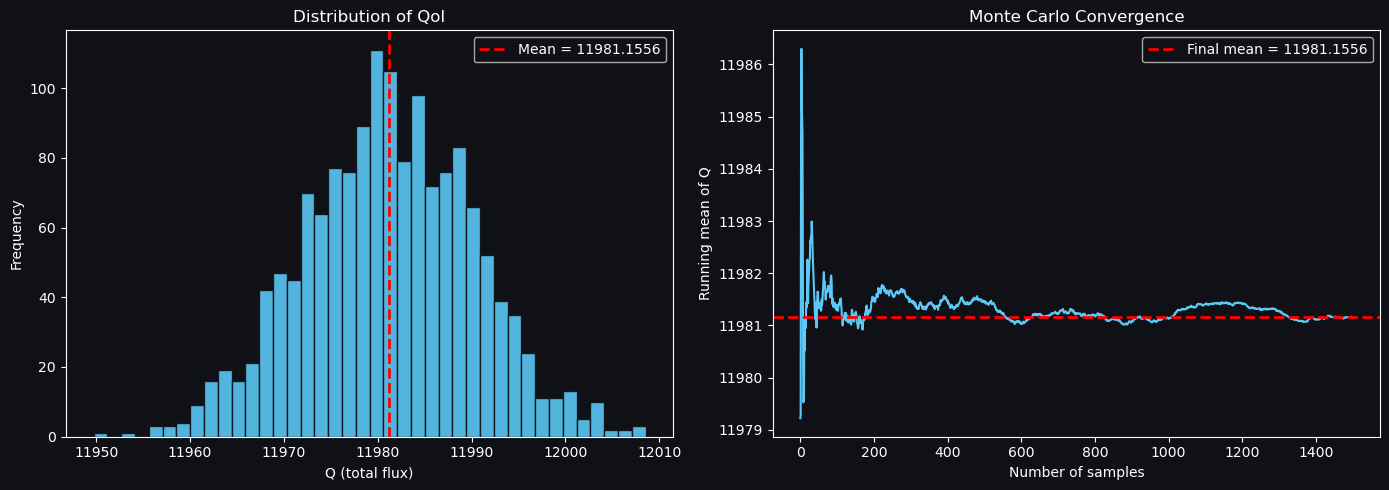

In [51]:
analyze_qoi(Q_samples)

In [53]:
# 6. Run the hardened Monte Carlo loop
Q_samples = monte_carlo_loop_tqdm(
    L_sigma, lambda_min, edges, n_vertices,
    gamma_in, gamma_out, edge_weights,
    N=750, debug=True
)

Monte Carlo: 100%|██████████| 750/750 [01:34<00:00,  7.92sample/s, mean Q=11982.0401]


✓ Done — 750 samples
  Mean Q : 11982.040127
  Std Q  : 9.096514



=== Monte Carlo Results ===
  Samples : 750
  Mean Q  : 11982.040127
  Std Q   : 9.096514
  Var Q   : 82.746562
  Min Q   : 11956.767630
  Max Q   : 12009.549688


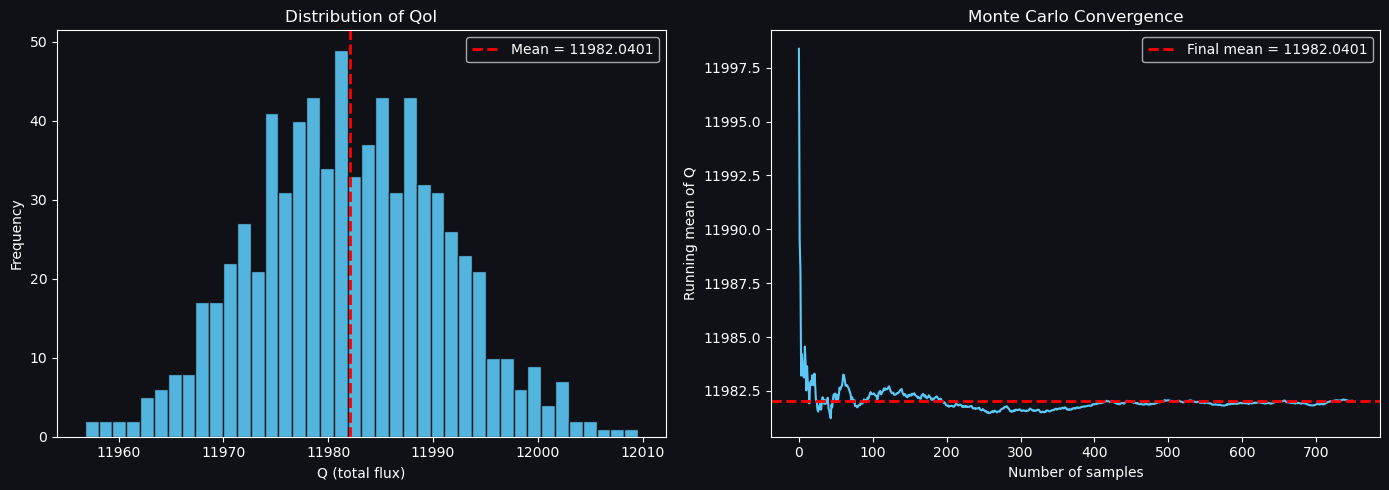

In [55]:
analyze_qoi(Q_samples)